# 05 - Bayesian Decision Rule


In [1]:
import os
import sys
from pathlib import Path

_cwd = Path(os.getcwd())
for _root in [_cwd, *_cwd.parents]:
    if (_root / "skin_lesion" / "src" / "config.py").exists():
        sys.path.insert(0, str(_root / "skin_lesion" / "src"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay)

from config import SEED, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, COST_FN, COST_FP, COST_MATRIX, HSV_BINS

## 1 - Load splits and GMMs

In [2]:
data = np.load(PROCESSED_DIR / "splits.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]

gmm_benign   = joblib.load(PROCESSED_DIR / "gmm_benign.pkl")
gmm_melanoma = joblib.load(PROCESSED_DIR / "gmm_melanoma.pkl")

print(f"Train: {len(y_train)} samples")
print(f"Val  : {len(y_val)}  samples")
print(f"Test : {len(y_test)} samples")
print(f"GMM benign   — K={gmm_benign.n_components},   cov='{gmm_benign.covariance_type}'")
print(f"GMM melanoma — K={gmm_melanoma.n_components}, cov='{gmm_melanoma.covariance_type}'")

Train: 1335 samples
Val  : 445  samples
Test : 446 samples
GMM benign   — K=2,   cov='full'
GMM melanoma — K=1, cov='full'


In [ ]:
#Explicit class priors
prior_mel = float(y_train.mean())       
prior_ben = 1.0 - prior_mel             

print(f"Prior P(melanoma) = {prior_mel:.6f}")
print(f"Prior P(benign)   = {prior_ben:.6f}")
print(f"(sum = {prior_mel + prior_ben:.6f})")

Prior P(melanoma) = 0.499625
Prior P(benign)   = 0.500375
(sum = 1.000000)


## 2 - Posterior computation 

In [4]:
def compute_posterior(X, gmm_mel, gmm_ben, prior_mel=0.5, prior_ben=0.5):
    """
    P(ω_M | x) for each row in X via the general Bayes rule.

    Uses log-space arithmetic (np.logaddexp for the normaliser) so it is
    numerically safe even for very large or very small log-likelihoods.

    Parameters
    ----------
    X         : (N, D) feature matrix
    gmm_mel   : fitted GaussianMixture for the melanoma class
    gmm_ben   : fitted GaussianMixture for the benign class
    prior_mel : P(ω_M) — scalar prior for melanoma
    prior_ben : P(ω_B) — scalar prior for benign  (must sum to 1 with prior_mel)

    Returns
    -------
    (N,) array of P(ω_M | x) values in [0, 1]
    """
    log_p_mel = gmm_mel.score_samples(X)           # log p(x | ω_M)
    log_p_ben = gmm_ben.score_samples(X)           # log p(x | ω_B)

    log_num = log_p_mel + np.log(prior_mel)        # log[ p(x|ω_M) · P(ω_M) ]
    log_den = log_p_ben + np.log(prior_ben)        # log[ p(x|ω_B) · P(ω_B) ]
    log_evidence = np.logaddexp(log_num, log_den)  # log normaliser (numerically stable)

    return np.exp(np.clip(log_num - log_evidence, -500, 0))


post_val  = compute_posterior(X_val,  gmm_melanoma, gmm_benign, prior_mel, prior_ben)
post_test = compute_posterior(X_test, gmm_melanoma, gmm_benign, prior_mel, prior_ben)

print(f"Posterior P(mel|x) - val  : mean={post_val.mean():.4f}, "
      f"min={post_val.min():.4f}, max={post_val.max():.4f}")
print(f"Posterior P(mel|x) - test : mean={post_test.mean():.4f}, "
      f"min={post_test.min():.4f}, max={post_test.max():.4f}")

Posterior P(mel|x) - val  : mean=0.5617, min=0.0000, max=1.0000
Posterior P(mel|x) - test : mean=0.5303, min=0.0000, max=1.0000


## 3 - Conditional risk and decision rules

In [ ]:
def conditional_risk(posteriors_2d, cost_matrix):
    """
    R(α_i | x) = Σ_j λ(α_i | ω_j) · P(ω_j | x)  for every sample and action.

    Parameters
    ----------
    posteriors_2d : (N, C) array  — P(ω_j | x); rows sum to 1
    cost_matrix   : (A, C) array  — λ[i, j] = cost of action i when true class is j

    Returns
    -------
    risks : (N, A) array — conditional risk for each sample × action
    """
    return posteriors_2d @ cost_matrix.T     # (N, C) × (C, A) → (N, A)


def min_risk_decision(posteriors_2d, cost_matrix):
    """Return the minimum-risk action index (0=benign, 1=melanoma) for each sample."""
    return np.argmin(conditional_risk(posteriors_2d, cost_matrix), axis=1)


# ── Build (N, 2) posterior matrices: col-0 = P(benign|x), col-1 = P(mel|x) ──
post_2d_val  = np.column_stack([1 - post_val,  post_val])
post_2d_test = np.column_stack([1 - post_test, post_test])

# ── Verify: min-risk decisions must match the analytic cost-sensitive threshold ─
THRESH_COST = COST_FP / (COST_FP + COST_FN)   # 1/6 ≈ 0.1667

y_risk_test = min_risk_decision(post_2d_test, COST_MATRIX)
y_thr_test  = (post_test >= THRESH_COST).astype(int)

assert np.array_equal(y_risk_test, y_thr_test), \
    "min_risk_decision and cost-sensitive threshold diverged — check cost matrix!"
print("Verification passed: min_risk_decision == cost-sensitive threshold for all test samples.")
print(f"Cost-sensitive threshold : {THRESH_COST:.6f}  "
      f"(= COST_FP / (COST_FP + COST_FN) = {COST_FP} / {COST_FP + COST_FN})")


Verification passed: min_risk_decision == cost-sensitive threshold for all test samples.
Cost-sensitive threshold : 0.166667  (= COST_FP / (COST_FP + COST_FN) = 1.0 / 6.0)


In [6]:
THRESH_MAP = 0.5

print(f"MAP threshold            : {THRESH_MAP}")
print(f"Cost-sensitive threshold : {THRESH_COST:.6f}  (= {int(COST_FP)}/{int(COST_FP+COST_FN)})\n")


def evaluate(y_true, posterior, threshold, rule_name, split_name):
    y_pred = (posterior >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc  = accuracy_score(y_true, y_pred)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall for melanoma (TPR)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # recall for benign  (TNR)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0   # precision for melanoma
    f1   = (2 * prec * sens / (prec + sens)) if (prec + sens) > 0 else 0.0
    cost = COST_FN * fn + COST_FP * fp
    print(f"[{split_name} | {rule_name}]")
    print(f"  Accuracy={acc:.4f}  Sensitivity={sens:.4f}  Specificity={spec:.4f}")
    print(f"  Precision={prec:.4f}  F1={f1:.4f}")
    print(f"  FN={fn}  FP={fp}  Total cost={cost:.0f}\n")
    return dict(rule=rule_name, split=split_name, threshold=round(threshold, 6),
                accuracy=round(acc, 4), sensitivity=round(sens, 4),
                specificity=round(spec, 4), precision=round(prec, 4),
                f1=round(f1, 4), FN=int(fn), FP=int(fp),
                total_cost=int(cost), cm=cm)


records = []
for split_name, y_true, post in [("val",  y_val,  post_val),
                                  ("test", y_test, post_test)]:
    records.append(evaluate(y_true, post, THRESH_MAP,  "MAP",            split_name))
    records.append(evaluate(y_true, post, THRESH_COST, "cost-sensitive", split_name))


MAP threshold            : 0.5
Cost-sensitive threshold : 0.166667  (= 1/6)

[val | MAP]
  Accuracy=0.7056  Sensitivity=0.7668  Specificity=0.6441
  Precision=0.6840  F1=0.7230
  FN=52  FP=79  Total cost=339

[val | cost-sensitive]
  Accuracy=0.7034  Sensitivity=0.7848  Specificity=0.6216
  Precision=0.6757  F1=0.7261
  FN=48  FP=84  Total cost=324

[test | MAP]
  Accuracy=0.7332  Sensitivity=0.7668  Specificity=0.6996
  Precision=0.7185  F1=0.7419
  FN=52  FP=67  Total cost=327

[test | cost-sensitive]
  Accuracy=0.7309  Sensitivity=0.7713  Specificity=0.6906
  Precision=0.7137  F1=0.7414
  FN=51  FP=69  Total cost=324



In [7]:
def threshold_shift_analysis(y_true, posterior, low, high, split_name):
    mask = (posterior >= low) & (posterior < high)
    n = mask.sum()
    n_mel = ((y_true == 1) & mask).sum()
    n_nev = ((y_true == 0) & mask).sum()

    print(f"{split_name}: samples flipped from MAP benign to cost-sensitive melanoma")
    print(f"  total flipped: {n}")
    print(f"  true melanoma among flipped: {n_mel}")
    print(f"  true nevus among flipped: {n_nev}")

threshold_shift_analysis(y_val, post_val, THRESH_COST, THRESH_MAP, "val")
threshold_shift_analysis(y_test, post_test, THRESH_COST, THRESH_MAP, "test")

val: samples flipped from MAP benign to cost-sensitive melanoma
  total flipped: 9
  true melanoma among flipped: 4
  true nevus among flipped: 5
test: samples flipped from MAP benign to cost-sensitive melanoma
  total flipped: 3
  true melanoma among flipped: 1
  true nevus among flipped: 2


## 4 - Confusion matrices on the test set

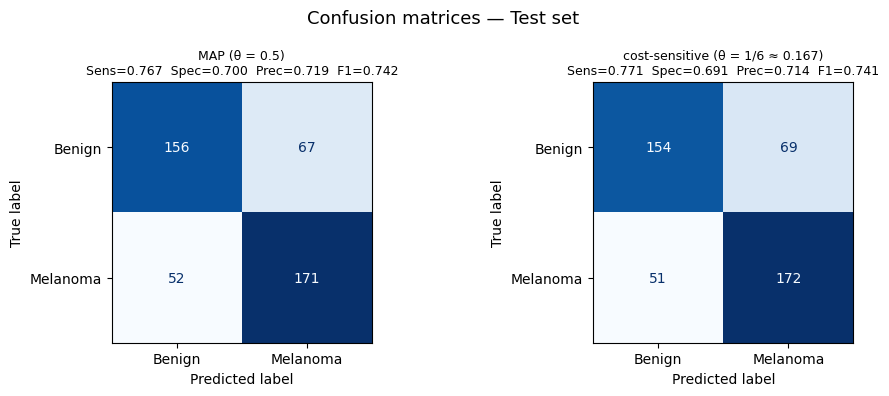

Figure saved to: C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\results\figures\confusion_matrices.png


In [8]:
test_records = {r["rule"]: r for r in records if r["split"] == "test"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Confusion matrices — Test set", fontsize=13)

for ax, (rule, res) in zip(axes, test_records.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res["cm"],
        display_labels=["Benign", "Melanoma"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    thresh_label = "0.5" if rule == "MAP" else "1/6 ≈ 0.167"
    ax.set_title(f"{rule} (θ = {thresh_label})\n"
                 f"Sens={res['sensitivity']:.3f}  Spec={res['specificity']:.3f}  "
                 f"Prec={res['precision']:.3f}  F1={res['f1']:.3f}",
                 fontsize=9)

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {FIGURES_DIR / 'confusion_matrices.png'}")


## 5 - Summary 

In [9]:
summary_cols = ["rule", "threshold", "accuracy", "sensitivity",
                "specificity", "precision", "f1", "FN", "FP", "total_cost"]
test_df = pd.DataFrame(
    [{k: r[k] for k in summary_cols} for r in records if r["split"] == "test"]
)
print(test_df.to_string(index=False))

TABLES_DIR.mkdir(parents=True, exist_ok=True)
test_df.to_csv(TABLES_DIR / "decision_comparison.csv", index=False)
print(f"\nSaved to: {TABLES_DIR / 'decision_comparison.csv'}")


          rule  threshold  accuracy  sensitivity  specificity  precision     f1  FN  FP  total_cost
           MAP   0.500000    0.7332       0.7668       0.6996     0.7185 0.7419  52  67         327
cost-sensitive   0.166667    0.7309       0.7713       0.6906     0.7137 0.7414  51  69         324

Saved to: C:\Users\minef\Downloads\Skin\skin_lesion_triage\skin_lesion\results\tables\decision_comparison.csv
